# Topic 1C: Data Visualization with Matplotlib & Seaborn
**Module 1 - Introduction to Machine Learning in Python**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Use the same sample data from Topic 1B (or load your own)
np.random.seed(42)
n = 5000
df = pd.DataFrame({
    'loan_amnt': np.random.lognormal(9.5, 0.5, n).round(0),
    'annual_income': np.random.lognormal(11, 0.7, n).round(0),
    'int_rate': np.random.uniform(5, 25, n).round(2),
    'dti': np.random.uniform(0, 40, n).round(2),
    'grade': np.random.choice(['A','B','C','D','E','F','G'], n, p=[0.15,0.25,0.25,0.15,0.10,0.06,0.04]),
    'home_ownership': np.random.choice(['RENT','MORTGAGE','OWN'], n, p=[0.42,0.43,0.15]),
})
grade_prob = {'A':0.03,'B':0.05,'C':0.08,'D':0.12,'E':0.18,'F':0.25,'G':0.35}
df['default'] = df['grade'].map(grade_prob).apply(lambda p: np.random.binomial(1, p))


## 1. Distribution Plots (2x2 Grid)


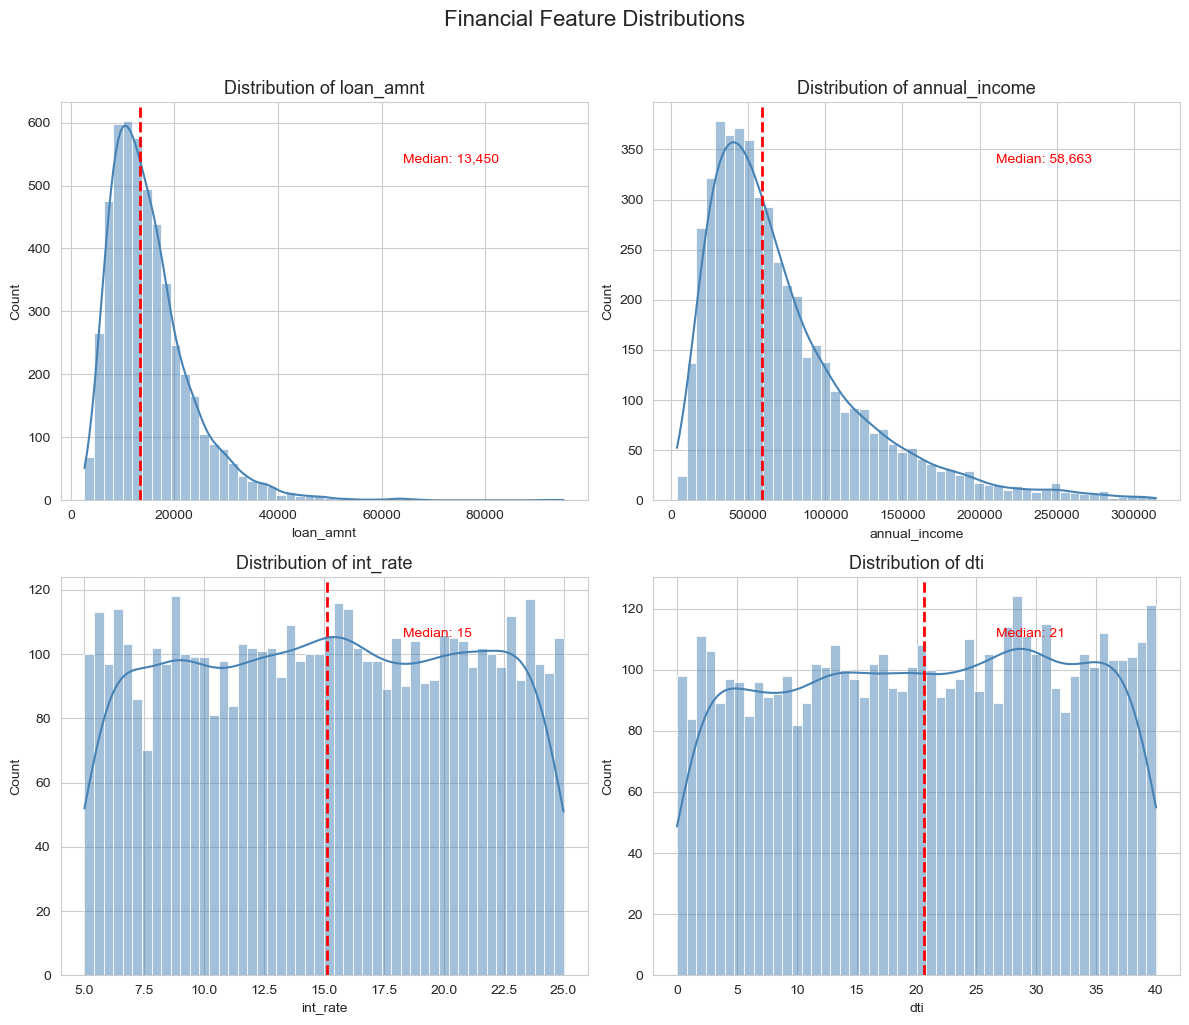

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['loan_amnt', 'annual_income', 'int_rate', 'dti']

for ax, feat in zip(axes.flatten(), features):
    data = df[feat].dropna()
    if feat == 'annual_income':
        data = data[data < data.quantile(0.99)]  # Trim outliers for visualization
    sns.histplot(data, bins=50, ax=ax, kde=True, color='steelblue')
    median_val = data.median()
    ax.axvline(x=median_val, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Distribution of {feat}', fontsize=13)
    ax.annotate(f'Median: {median_val:,.0f}', xy=(0.65, 0.85), xycoords='axes fraction',
                fontsize=10, color='red')

plt.suptitle('Financial Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 2. Correlation Heatmap


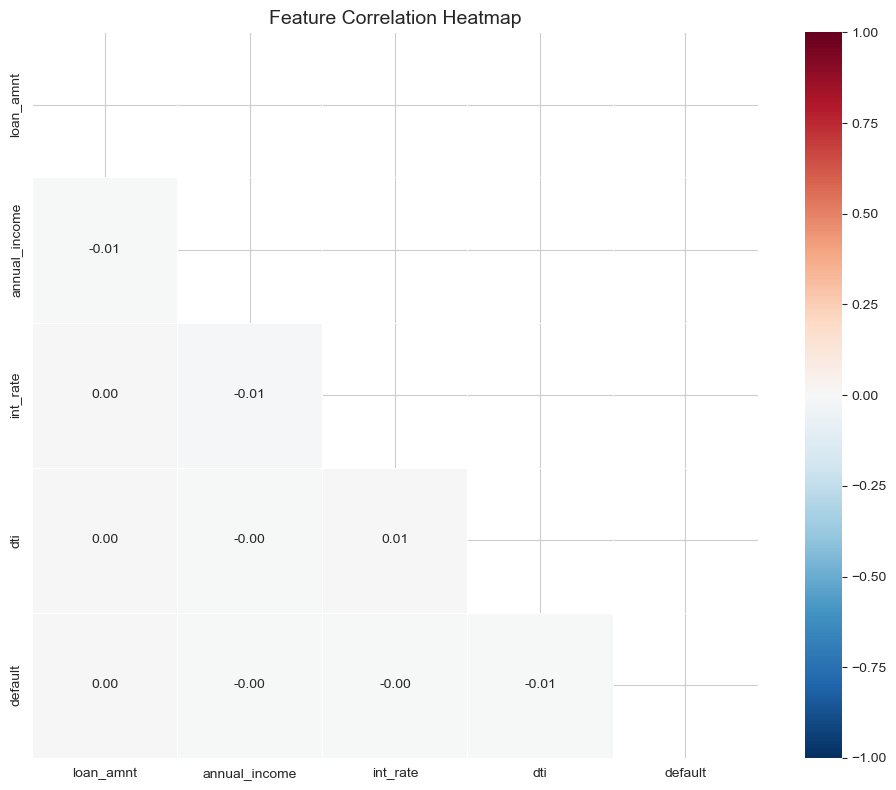

High correlation pairs (|r| > 0.7): None found


In [3]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
print('High correlation pairs (|r| > 0.7):', high_corr if high_corr else 'None found')


## 3. Default Rate by Segment (Bar Charts)


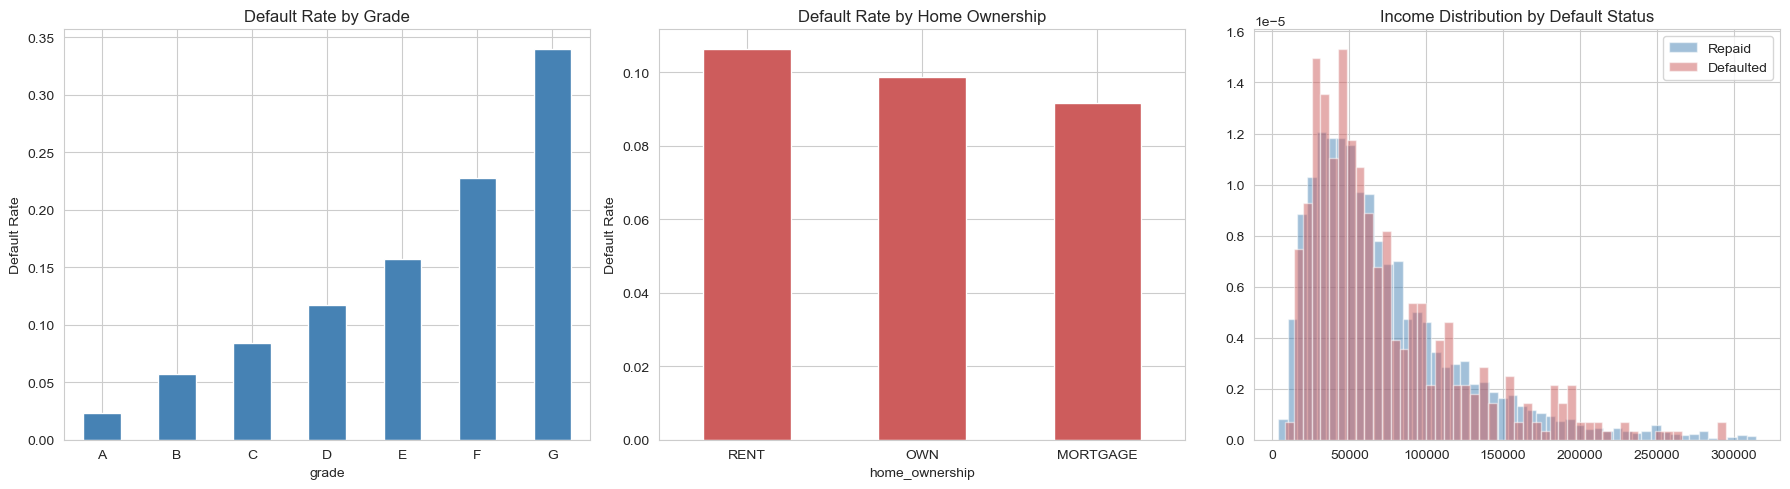

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Default rate by grade
grade_rates = df.groupby('grade')['default'].mean().sort_index()
grade_rates.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Default Rate by Grade')
axes[0].set_ylabel('Default Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Default rate by home ownership
home_rates = df.groupby('home_ownership')['default'].mean().sort_values(ascending=False)
home_rates.plot(kind='bar', ax=axes[1], color='indianred', edgecolor='white')
axes[1].set_title('Default Rate by Home Ownership')
axes[1].set_ylabel('Default Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Income distribution by default status
income_repaid = df[df['default']==0]['annual_income']
income_default = df[df['default']==1]['annual_income']
income_repaid = income_repaid[income_repaid < income_repaid.quantile(0.99)]
income_default = income_default[income_default < income_default.quantile(0.99)]
axes[2].hist(income_repaid, bins=50, alpha=0.5, label='Repaid', density=True, color='steelblue')
axes[2].hist(income_default, bins=50, alpha=0.5, label='Defaulted', density=True, color='indianred')
axes[2].set_title('Income Distribution by Default Status')
axes[2].legend()

plt.tight_layout()
plt.show()


## 4. Box Plots for Comparing Distributions


C:\Users\TeresaZhu\AppData\Local\Temp\ipykernel_18292\98850619.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grade', y='dti', order=['A','B','C','D','E','F','G'],
C:\Users\TeresaZhu\AppData\Local\Temp\ipykernel_18292\98850619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grade', y='int_rate', order=['A','B','C','D','E','F','G'],


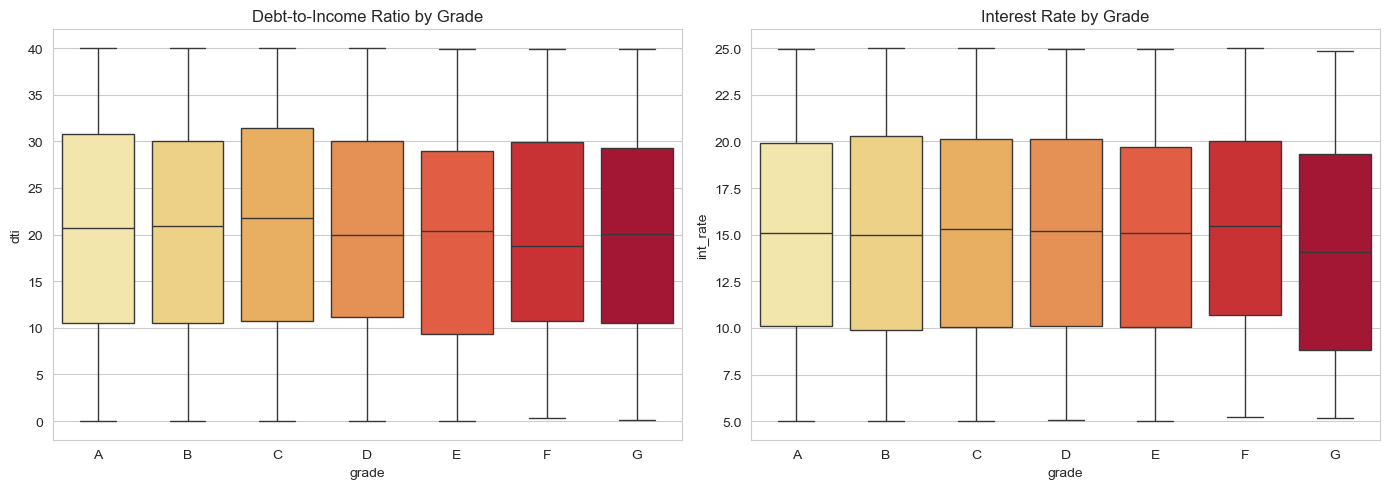

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# DTI by grade
sns.boxplot(data=df, x='grade', y='dti', order=['A','B','C','D','E','F','G'], 
            ax=ax1, palette='YlOrRd')
ax1.set_title('Debt-to-Income Ratio by Grade')

# Interest rate by grade
sns.boxplot(data=df, x='grade', y='int_rate', order=['A','B','C','D','E','F','G'],
            ax=ax2, palette='YlOrRd')
ax2.set_title('Interest Rate by Grade')

plt.tight_layout()
plt.show()


## 5. Scatter Plot with Default Overlay


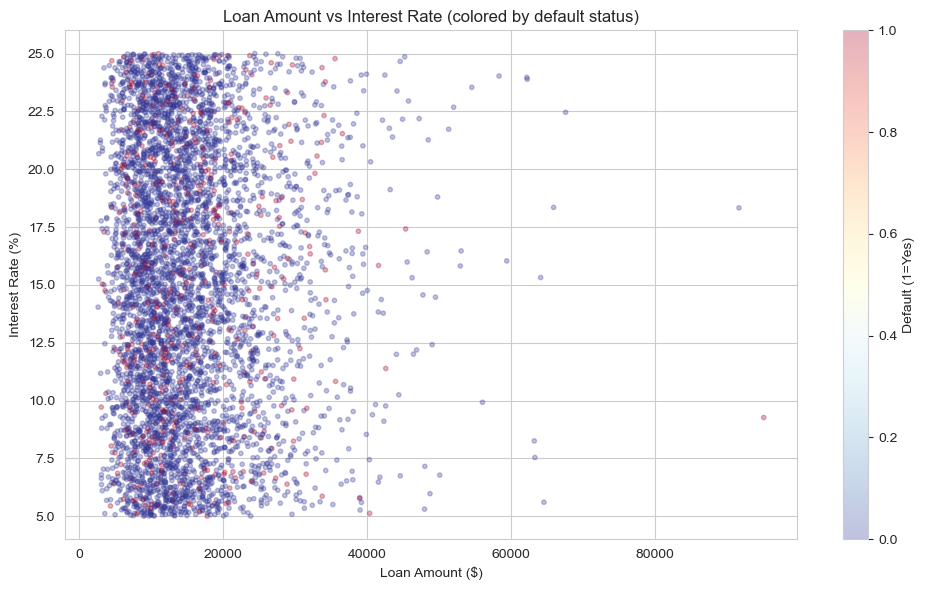

In [6]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['loan_amnt'], df['int_rate'], 
                     c=df['default'], cmap='RdYlBu_r', alpha=0.3, s=10)
plt.colorbar(scatter, label='Default (1=Yes)')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Interest Rate (%)')
plt.title('Loan Amount vs Interest Rate (colored by default status)')
plt.tight_layout()
plt.show()
